importing libraries

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import joblib

importing dataset

In [35]:
# file_path="/content/partpdf_1772778618075_partpdf_1763620814447_airbnb.xlsx"


In [36]:
df=pd.read_excel("/content/partpdf_1772778618075_partpdf_1763620814447_airbnb (1).xlsx")
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
1,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
2,1039,2008-07-25,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0
3,1783,2008-08-12,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0
4,2078,2008-08-15,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0


In [37]:

df['Host Since'] = pd.to_datetime(df['Host Since'], errors='coerce')
df['Host_Year'] = df['Host Since'].dt.year
df['Host_Month'] = df['Host Since'].dt.month

In [38]:
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,Host_Year,Host_Month
0,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN,2008,6
1,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0,2008,6
2,1039,2008-07-25,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0,2008,7
3,1783,2008-08-12,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0,2008,8
4,2078,2008-08-15,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0,2008,8


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30475 entries, 0 to 30474
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Host Id                     30475 non-null  int64         
 1   Host Since                  30475 non-null  datetime64[ns]
 2   Name                        30475 non-null  object        
 3   Neighbourhood               30475 non-null  object        
 4   Property Type               30472 non-null  object        
 5   Review Scores Rating (bin)  22155 non-null  float64       
 6   Room Type                   30475 non-null  object        
 7   Zipcode                     30341 non-null  float64       
 8   Beds                        30390 non-null  float64       
 9   Number of Records           30475 non-null  int64         
 10  Number Of Reviews           30475 non-null  int64         
 11  Price                       30475 non-null  int64     

Newer hosts (recently joined) often have lower prices to build reputation
Established hosts with years of experience can command premium prices
Hosts active longer tend to have optimized pricing strategies

Hosts who started in peak season vs off-season may have different pricing strategies which can be idntifyied from month grouping.
Can reveal market conditions with respect to year and month

In [40]:
df.shape

(30475, 15)

In [41]:
df.nunique()

,0
Host Id,24418
Host Since,2240
Name,29414
Neighbourhood,5
Property Type,19
Review Scores Rating (bin),15
Room Type,3
Zipcode,188
Beds,14
Number of Records,1


In [42]:
df=df.drop('Host Id',axis=1)

In [43]:
df.isnull().sum()

,0
Host Since,0
Name,0
Neighbourhood,0
Property Type,3
Review Scores Rating (bin),8320
Room Type,0
Zipcode,134
Beds,85
Number of Records,0
Number Of Reviews,0


In [44]:

df['Property Type']=df['Property Type'].fillna(df['Property Type'].mode()[0])

In [45]:
df['Zipcode'] = df['Zipcode'].fillna(df['Zipcode'].median())
df['Review Scores Rating'] = df['Review Scores Rating'].fillna(df['Review Scores Rating'].median())
df['Beds'] = df['Beds'].fillna(df['Beds'].median())
df['Review Scores Rating (bin)'] = df['Review Scores Rating (bin)'].fillna(df['Review Scores Rating (bin)'].median())


#since property type is an object column, it filled with mode. rest of the other columns are filled with median because median is the only method that can apply to any dataset regardless of its distribution. mesaures like mean only can apply to if the feature follow normal distribution

In [46]:
df.isnull().sum()

,0
Host Since,0
Name,0
Neighbourhood,0
Property Type,0
Review Scores Rating (bin),0
Room Type,0
Zipcode,0
Beds,0
Number of Records,0
Number Of Reviews,0


In [47]:
df=df.drop('Host Since',axis=1)

In [48]:
cat_cols=df.select_dtypes(include=['object'])
num_cols=df.select_dtypes(include=['float64','int32','int64'])

In [49]:
df.duplicated().sum()

np.int64(18)

In [50]:
df=df.drop_duplicates()

In [51]:
new_df=df.copy()

In [52]:
df.columns

Index(['Name', 'Neighbourhood ', 'Property Type', 'Review Scores Rating (bin)',
       'Room Type', 'Zipcode', 'Beds', 'Number of Records',
       'Number Of Reviews', 'Price', 'Review Scores Rating', 'Host_Year',
       'Host_Month'],
      dtype='object')

In [53]:
df['Neighbourhood_RoomType'] = df['Neighbourhood '] + '_' + df['Room Type']

In [54]:
cat_cols=df.select_dtypes(include=['object'])
num_cols=df.select_dtypes(include=['float64','int32','int64'])

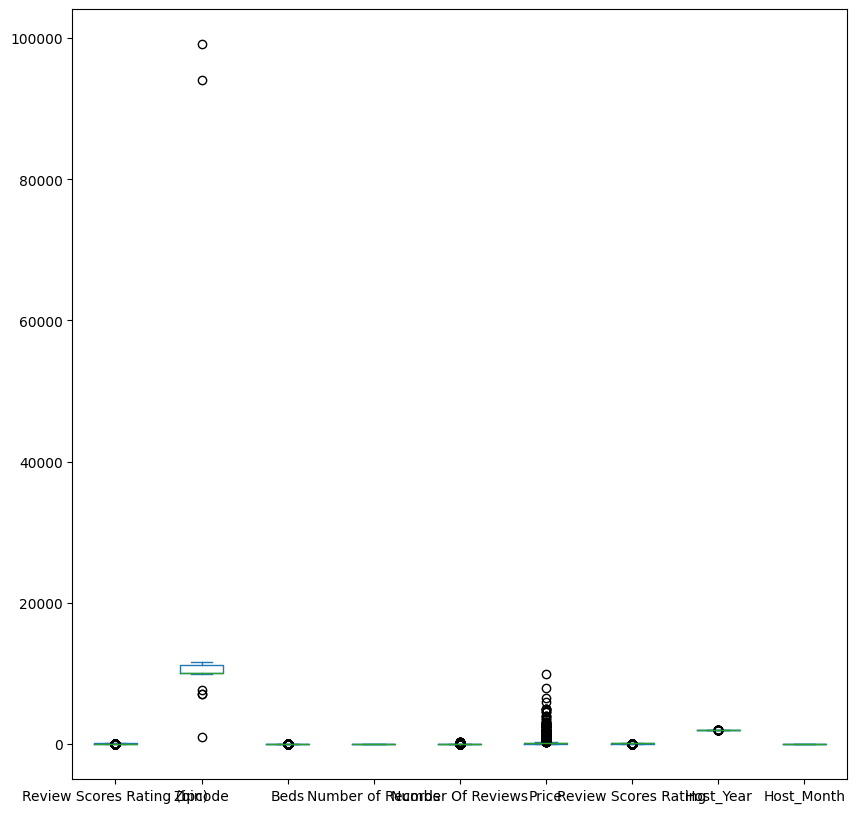

In [55]:
data=df.plot(kind='box',figsize=(10,10))

In [56]:
q1=num_cols.quantile(0.25)
q3=num_cols.quantile(0.75)
IQR=q3-q1

df[num_cols.columns]=num_cols.clip(
    lower=q1-(1.5*IQR),
    upper=q3+(1.5*IQR),
    axis=1
)

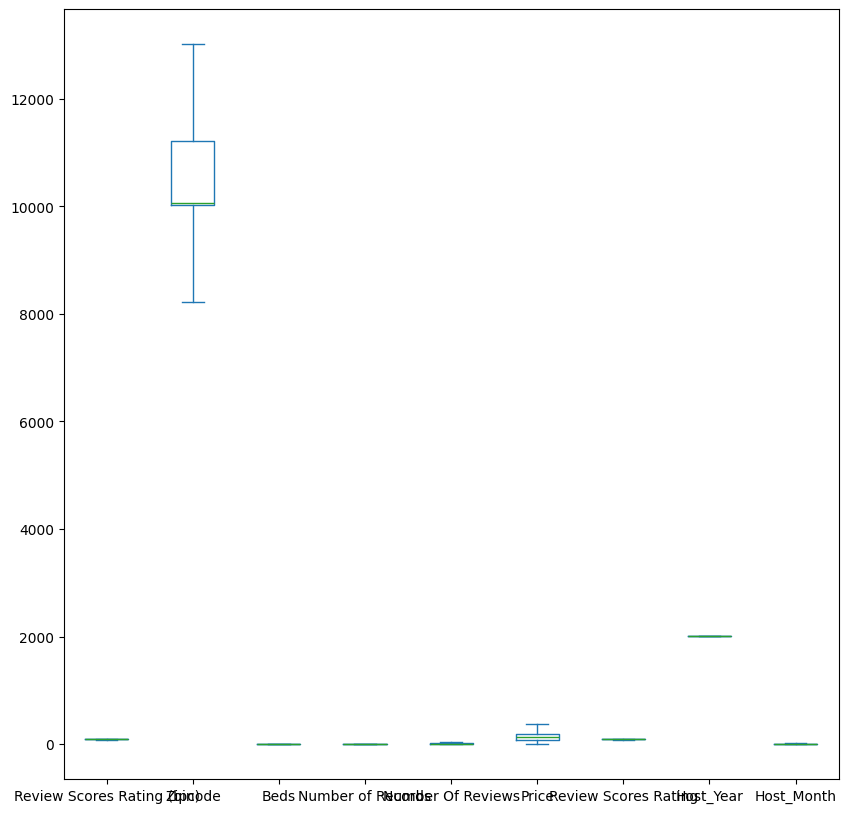

In [57]:
data=df.plot(kind='box',figsize=(10,10))

Encoding

In [58]:
df.shape

(30457, 14)

In [60]:
cat_cols.columns

Index(['Name', 'Neighbourhood ', 'Property Type', 'Room Type',
       'Neighbourhood_RoomType'],
      dtype='object')

In [61]:
cat_cols.nunique()

,0
Name,29414
Neighbourhood,5
Property Type,19
Room Type,3
Neighbourhood_RoomType,15


In [62]:
cat_cols=cat_cols.drop('Name',axis=1)
df=df.drop('Name',axis=1)


In [81]:

new_df=new_df.drop('Name',axis=1)


In [67]:
df=pd.get_dummies(df,drop_first=True,dtype=int)

In [83]:
new_df=pd.get_dummies(df,drop_first=True,dtype=int)

In [63]:

from sklearn.preprocessing import StandardScaler

In [68]:
X=df.drop('Price',axis=1)
y=df['Price']

In [84]:
X=new_df.drop('Price',axis=1)
y=new_df['Price']

In [70]:
columns = X.columns

import joblib
joblib.dump(columns, "columns.pkl")


['columns.pkl']

In [72]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [73]:
sscaler=StandardScaler()
X_train = sscaler.fit_transform(X_train)  # learn from train
X_test = sscaler.transform(X_test)

In [74]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor


In [75]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
# Evaluate
print("R2 Score:", r2_score(y_test, rf_preds))
print("MAE:", mean_absolute_error(y_test, rf_preds))
print("MSE:", mean_squared_error(y_test, rf_preds))

R2 Score: 0.5588999495579143
MAE: 39.16935102948059
MSE: 3129.323442092628


In [76]:
from sklearn.model_selection import RandomizedSearchCV

fast_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 15, 30],
    'min_samples_split': [2, 10],
    'max_features': ['sqrt']
}

rf = RandomForestRegressor()
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=fast_grid,n_iter=5, cv=3, verbose=1,random_state=42, n_jobs=-1)

rf_random.fit(X_train, y_train)

print("Best Parameters found:", rf_random.best_params_)


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters found: {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 15}


In [77]:
fast_preds = rf_random.predict(X_test)
print(f"Fast Tuned R2: {r2_score(y_test, fast_preds)}")

Fast Tuned R2: 0.587044922789123


using radomforestregressor initially i got r2 score value of 55, then i did find tunin(randomizessearcchcv) to identify best parameters. after fine tuning it incresed upto a score of 58

In [79]:
import pickle

# save model
with open('model.pkl', 'wb') as f:
    pickle.dump(rf_random.best_estimator_, f)

# save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(sscaler, f)